In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from quantem.tomography.dataset_models import TomographyPixDataset, TomographyINRDataset
from quantem.tomography.tomography_lite import TomographyLiteConv, TomographyLiteINR
import numpy as np
from quantem.core.visualization import show_2d

from quantem.tomography.utils import fourier_cropping

/home/cedlim/quantem/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load Phantom Dataset
tilt_series = np.load('../../../data/tilt_series.npy')
tilt_angles = np.load('../../../data/tilt_angles.npy')

# Fourier crop
tilt_series = np.array([fourier_cropping(img, (100, 100)) for img in tilt_series]) # Cropped down to 100x100 for speed


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

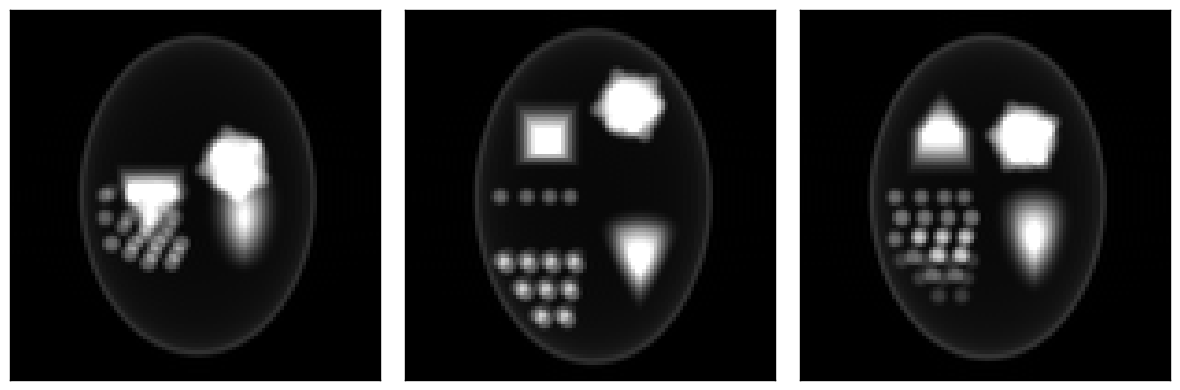

In [4]:
show_2d(
    [tilt_series[0], tilt_series[30], tilt_series[60]],
)

# Conventional Tomography Reconstructions
*Cedric Lim, 2/1/26*

In [ ]:
device = "cuda:0" # Set device

In [ ]:
# Initialize dataset
dset = TomographyPixDataset(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)

In [ ]:
tomography = TomographyLiteConv.from_dataset(
    dset,
    device = device
)

Device trying to set:  cuda:0


In [6]:
tomography.reconstruct(
    num_iter = 10,
    inline_alignment = True,
    smoothing_sigma = 0.5,
)

sirt Reconstruction:   0%|          | 0/10 [00:00<?, ?it/s]

proj_forward.shape torch.Size([100, 71, 100])
self.dset.tilt_stack.shape torch.Size([71, 100, 100])


sirt Reconstruction | Loss: 0.0213: 100%|██████████| 10/10 [00:00<00:00, 10.35it/s]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

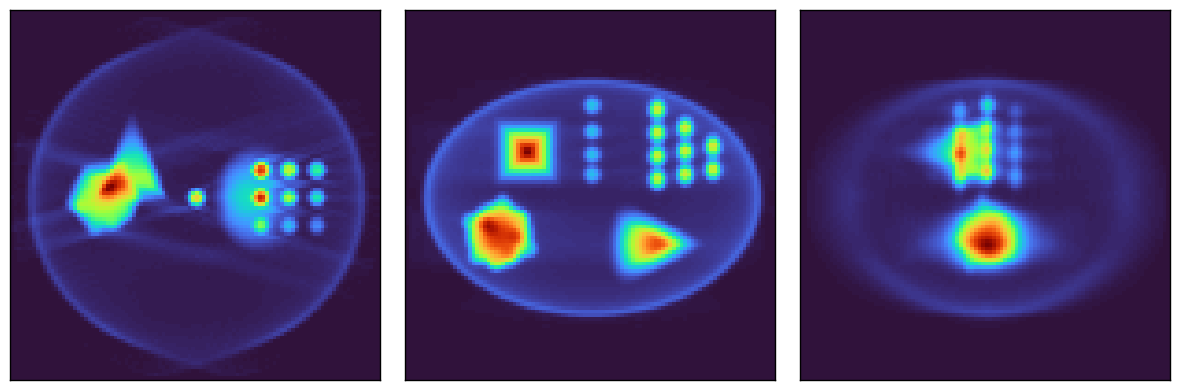

In [7]:
obj = tomography.obj_model.obj.detach().cpu().numpy()
show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

# INR-Based Tomography Reconstruction

In [ ]:
dset = TomographyINRDataset(
    tilt_stack = tilt_series,
    tilt_angles = tilt_angles,
)
tomography_inr = TomographyLiteINR.from_dataset(
    dset,
    device = device,
    log_dir = '../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite',
    log_images_every = 2,
)


Single GPU training
Model built, compiled successfully
Single GPU training
Device trying to set:  cuda:0
Setting up DDP for obj_model
Single GPU training
Device trying to set:  cuda:0


In [9]:
constraints = {
    "positivity": True,
    "tv_vol": 1e-6,
}
tomography_inr.reconstruct(
    num_iter = 50,
    # reset = True,
    obj_lr = 1e-4,
    pose_lr = 1e-2,
    batch_size = 1024,
    num_workers = 32,
    learn_pose = True,
    scheduler_type = "cosine_annealing",
    constraints = constraints,
)

Dataloader setup complete:
  Total train samples: 710000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 693
N: 100, num_samples_per_ray: 100
curr_num_samples_per_ray: 100


/home/cedlim/quantem/quantem/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Total Loss: 0.0240, Consistency Loss: 0.0240
curr_num_samples_per_ray: 100
Total Loss: 0.0014, Consistency Loss: 0.0013
Creating volume...
Logging images...
Logging volume...
Plotting z1 and z3 angles...
Plotting shifts...
curr_num_samples_per_ray: 100
Total Loss: 0.0005, Consistency Loss: 0.0004
curr_num_samples_per_ray: 100
Total Loss: 0.0003, Consistency Loss: 0.0003
Creating volume...
Logging images...
Logging volume...
Plotting z1 and z3 angles...
Plotting shifts...
curr_num_samples_per_ray: 100
Total Loss: 0.0003, Consistency Loss: 0.0003
curr_num_samples_per_ray: 100
Total Loss: 0.0003, Consistency Loss: 0.0002
Creating volume...
Logging images...
Logging volume...
Plotting z1 and z3 angles...
Plotting shifts...
curr_num_samples_per_ray: 100
Total Loss: 0.0003, Consistency Loss: 0.0003
curr_num_samples_per_ray: 100
Total Loss: 0.0003, Consistency Loss: 0.0003
Creating volume...
Logging images...
Logging volume...
Plotting z1 and z3 angles...
Plotting shifts...
curr_num_samples_p

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

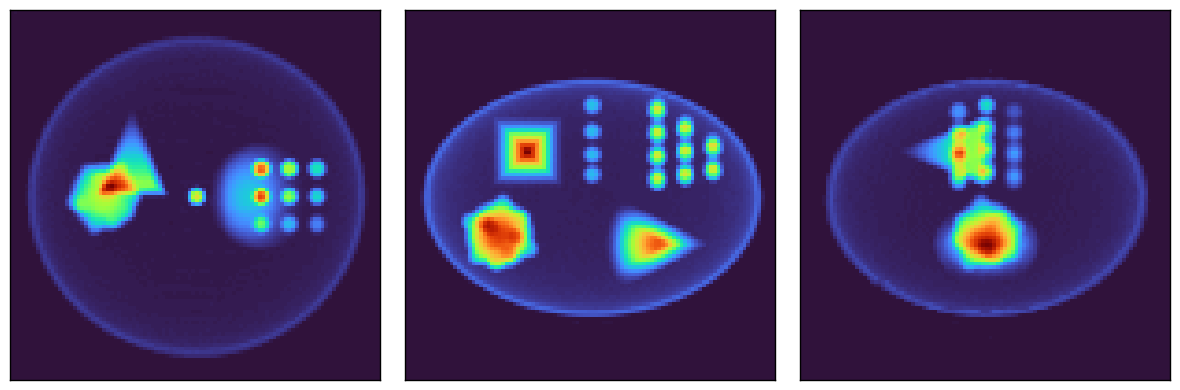

In [10]:
tomography_inr.obj_model.create_volume()
obj = tomography_inr.obj_model.obj.detach().cpu().numpy().transpose(0, 2, 1)
show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)